# 🧠 5.1 MLP Classification Model & Hyperparameter Tuning

En este notebook se entrena un clasificador basado en **Redes Neuronales con Gated Pooling y MLP** para la predicción binaria sobre los embeddings generados.

---

## 📋 Descripción General
El objetivo de este script es realizar un entrenamiento sistemático probando diferentes arquitecturas de red para identificar cuál maximiza el rendimiento en la clasificación de secuencias proteicas, integrando información fisicoquímica mediante un mecanismo de *gating*.

## 🛠️ Funcionalidades Principales

1.  **Arquitectura del Modelo (`GatedMLPClassifier`):**
    * Cabeza MLP flexible con capas `Linear`, `GELU`, `LayerNorm` y `Dropout` (para regularización y estabilidad numérica).
    * Capa de salida con logit directo para optimización estable con `BCEWithLogitsLoss`.
2.  **Entrenamiento y Optimización:**
    * Uso del optimizador **AdamW** con `weight_decay` y scheduler `ReduceLROnPlateau` para ajuste dinámico del learning rate.
    * Implementación de **Early Stopping** (`patience=12`, `min_delta=1e-4`) para detener el entrenamiento cuando la pérdida de validación se estanca.
    * Manejo automático de desbalanceo de clases mediante `pos_weight` calculado sobre el dataset de entrenamiento.
3.  **Búsqueda de Hiperparámetros:**
    * Evaluación comparativa de 3 configuraciones (`Gated_MLP_Small`, `Medium`, `Large`) variando profundidad, anchura de capas ocultas y tasa de dropout.
4.  **Monitoreo y Registro:**
    * Cálculo y registro de métricas por época (Loss, Accuracy, ROC-AUC, PR-AUC, F1, MCC).
    * Generación de curvas de entrenamiento, tablas comparativas y persistencia automática del mejor checkpoint junto con su historial y métricas de validación.

## 📦 Importación de Librerías

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de Rutas e Hiperparámetros

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/dataset-created")
OUT_DIR = Path("/kaggle/working/MLP_Results/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
L_MAX      = 100
INPUT_DIM   = 768      # Embedding dimension

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_MLP_Small",
        "hidden_dims": [256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_MLP_Medium",
        "hidden_dims": [512, 256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_MLP_Large",
        "hidden_dims": [1024, 512, 256, 128],
        "dropout": 0.4,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

## 🖥️ Inicialización de Hardware & Reproducibilidad

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

DEVICE: cuda


## 📊 Clase `AMPDataset` (PyTorch Dataset Custom)

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 📂 Carga de Datasets Serializados (`.pt`)

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## ✅ Carga y Validación Rápida

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13826 muestras
   val_ds  : 3614 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🧩 Función `collate_fn` para DataLoaders

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🔄 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=433, val=113
   ✅ X_b: (32, 100, 768) | G_b: (32, 768)


## 🔑 Mecanismo `GatedPooler`

In [9]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable.

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """

    def __init__(self, input_dim: int):
        super().__init__()

        # Gate aprendido desde el embedding de cada residuo
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Proyección opcional
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # X: (B, L, D)
        # M: (B, L)

        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)

        weighted = gates * self.proj(X)

        # Media ponderada
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates

## 🤖 Modelo `GatedMLPClassifier` y Verificación

In [10]:
class GatedMLPClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        # Pooling con atención/gating aprendido
        self.pooler = GatedPooler(input_dim=input_dim)

        # Embedding local + embedding global CLS
        layers = []
        in_features = input_dim * 2

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def forward(
        self,
        X: torch.Tensor,
        G: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:

        # Resumen local
        E = self.pooler(X, M)

        # Concatenar con embedding global CLS
        combined = torch.cat([E, G], dim=1)

        x = self.mlp_body(combined)
        return self.classifier(x)

    def get_gates(
        self,
        X: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:
        """Devuelve los gates por residuo para interpretabilidad."""

        gates = self.pooler.get_gates(X, M)   # (B, L, 1)
        return gates.squeeze(-1)              # (B, L)
    
def build_gated_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedMLPClassifier(
        input_dim,
        config["hidden_dims"],
        config["dropout"],
    )

# ========== SANITY CHECK ==========

_test_model = build_gated_model(ARCHITECTURES[0], INPUT_DIM)

_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_G = torch.randn(2, INPUT_DIM)

_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_G, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_M)

_n = sum(p.numel() for p in _test_model.parameters())

print(
    f"Sanity check ({ARCHITECTURES[0]['name']}): "
    f"params={_n:,}, "
    f"output shape={_test_out.shape}, "
    f"gates shape={_test_gates.shape}"
)

del _test_model, _test_X, _test_G, _test_M, _test_out, _test_gates

Sanity check (Gated_MLP_Small): params=1,116,418, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
        
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_gated_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # TRAIN
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Gb, Mb, yb in train_loader:
            Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Gb, Mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        # VAL
        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Gb, Mb, yb in val_loader:
                Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
                loss = criterion(model(Xb, Gb, Mb), yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
        val_loss /= n
        
        scheduler.step(val_loss)
        
        # Guardar métricas
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    start_time = time.time()
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    training_time = time.time() - start_time
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "training_time_sec": training_time,
        "config": config,
        "model": res["model"],
        "history": res["history"]
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_auc={v_metrics['roc_auc']:.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)



--- Entrenando Gated_MLP_Small ---
E01 | TL: 0.0634 | VL: 0.0559 | Val MCC: 0.7653 | B_ep: 1
E02 | TL: 0.0548 | VL: 0.0561 | Val MCC: 0.7492 | B_ep: 1
E03 | TL: 0.0524 | VL: 0.0530 | Val MCC: 0.7604 | B_ep: 3
E04 | TL: 0.0496 | VL: 0.0532 | Val MCC: 0.7661 | B_ep: 3
E05 | TL: 0.0464 | VL: 0.0520 | Val MCC: 0.7784 | B_ep: 5
E06 | TL: 0.0452 | VL: 0.0532 | Val MCC: 0.7759 | B_ep: 5
E07 | TL: 0.0447 | VL: 0.0531 | Val MCC: 0.7746 | B_ep: 5
E08 | TL: 0.0432 | VL: 0.0518 | Val MCC: 0.7940 | B_ep: 8
E09 | TL: 0.0407 | VL: 0.0538 | Val MCC: 0.7900 | B_ep: 8
E10 | TL: 0.0391 | VL: 0.0547 | Val MCC: 0.7919 | B_ep: 8
E11 | TL: 0.0391 | VL: 0.0578 | Val MCC: 0.7745 | B_ep: 8
E12 | TL: 0.0370 | VL: 0.0561 | Val MCC: 0.7905 | B_ep: 8
E13 | TL: 0.0363 | VL: 0.0523 | Val MCC: 0.8016 | B_ep: 8
E14 | TL: 0.0348 | VL: 0.0563 | Val MCC: 0.7738 | B_ep: 8
E15 | TL: 0.0311 | VL: 0.0612 | Val MCC: 0.8047 | B_ep: 8
E16 | TL: 0.0289 | VL: 0.0574 | Val MCC: 0.7897 | B_ep: 8
E17 | TL: 0.0286 | VL: 0.0630 | Val 

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
              Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   Gated_MLP_Large  2956034           7  0.049746  0.896237  0.875951  0.794623     0.953222    0.957511     142.5
1   Gated_MLP_Small  1116418           8  0.051798  0.896514  0.877377  0.793967     0.950904    0.954806     147.9
2  Gated_MLP_Medium  1642242           7  0.050387  0.892640  0.876590  0.783354     0.953796    0.957339     133.7

Saved

🏆 Best model: Gated_MLP_Large


## 📈 Visualización: Curvas de Entrenamiento Individuales

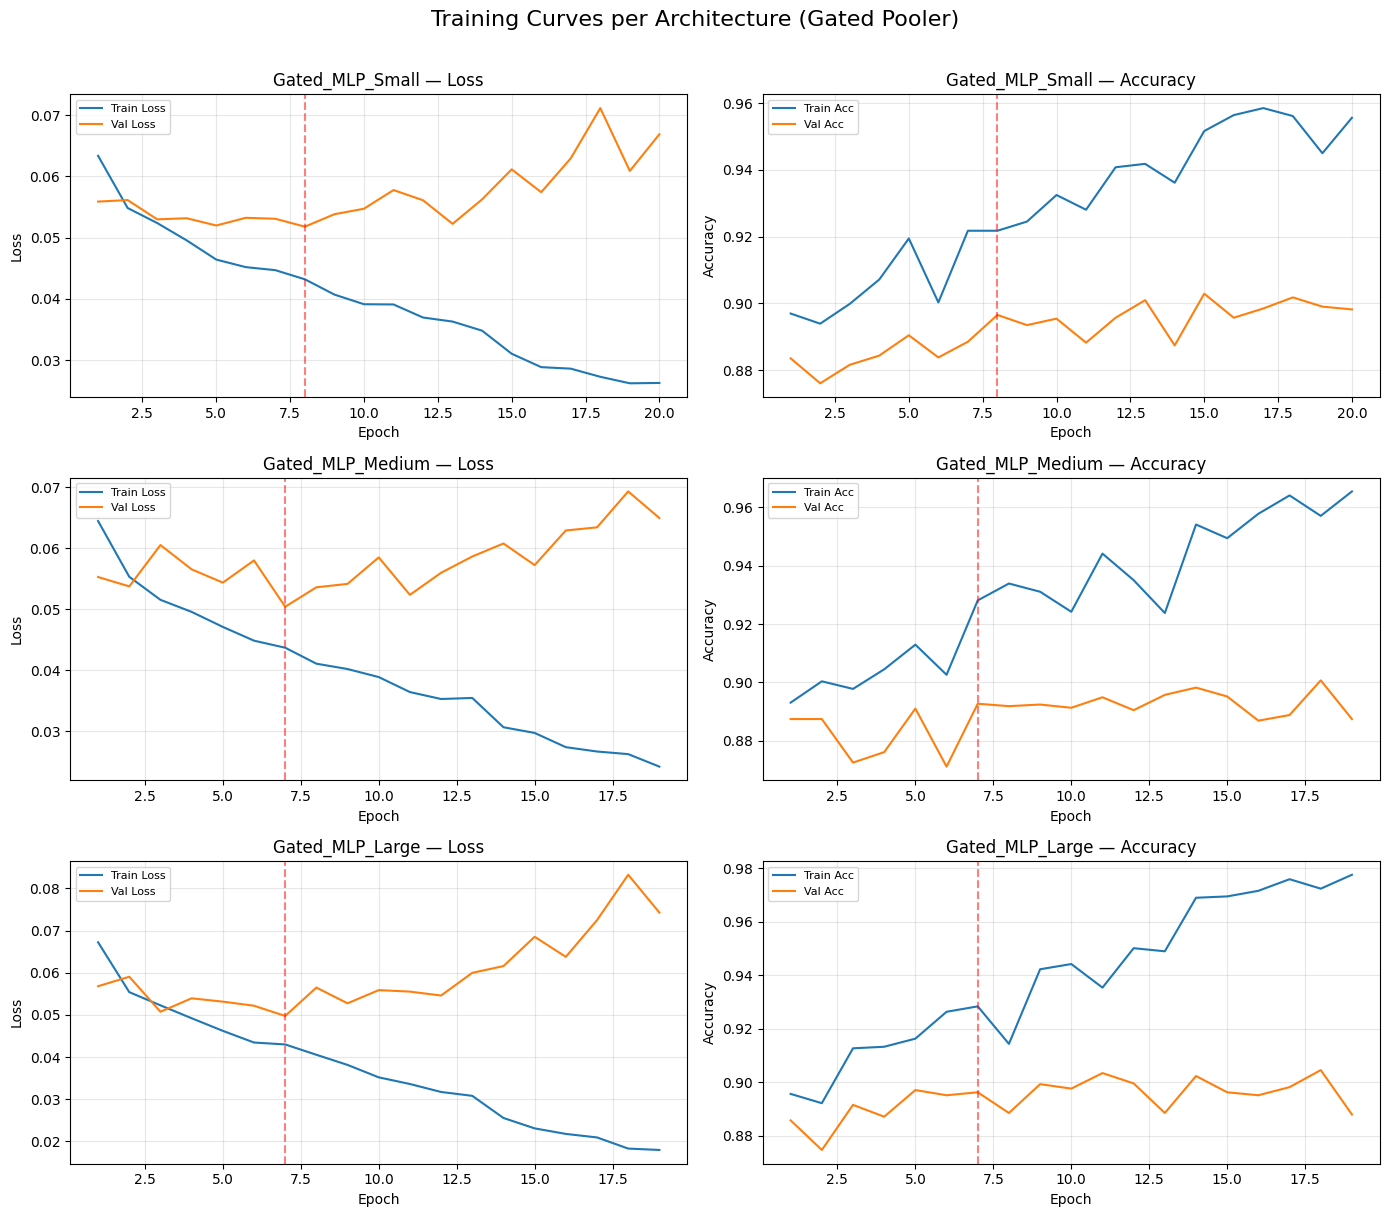

Saved: /kaggle/working/MLP_Results/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Comparación Directa entre Modelos

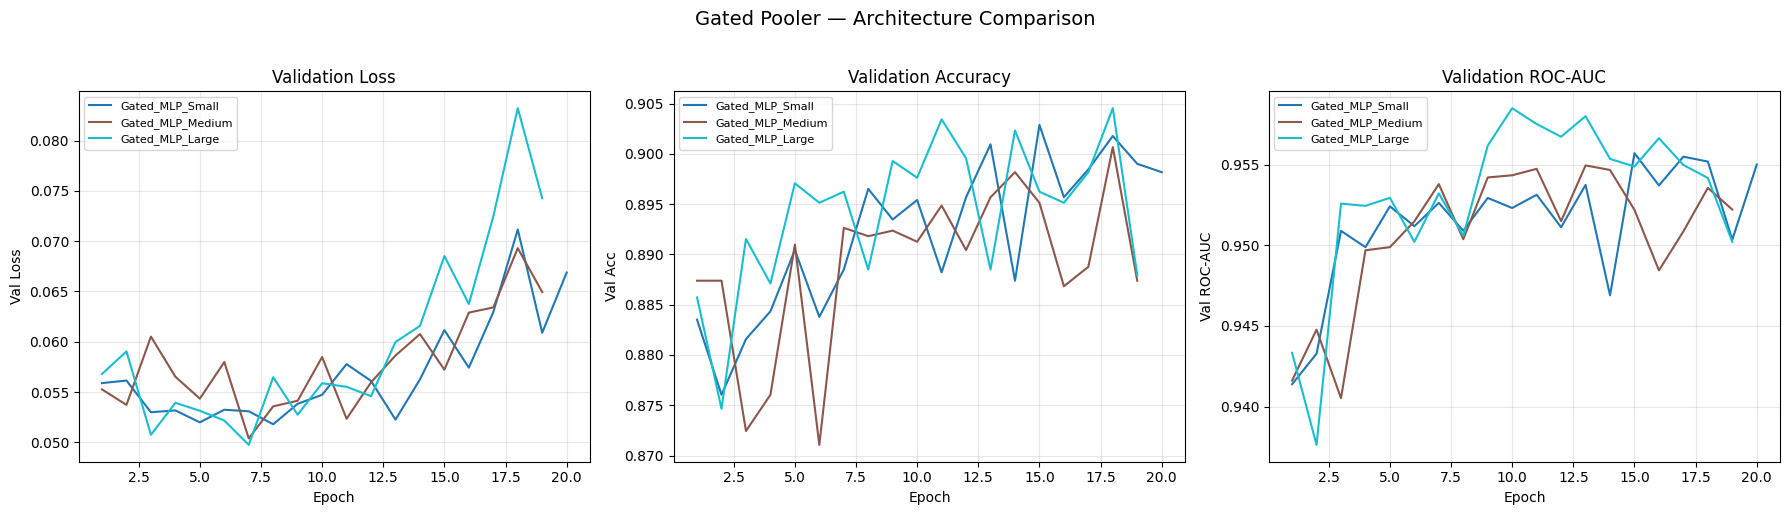

Saved: /kaggle/working/MLP_Results/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Acc"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

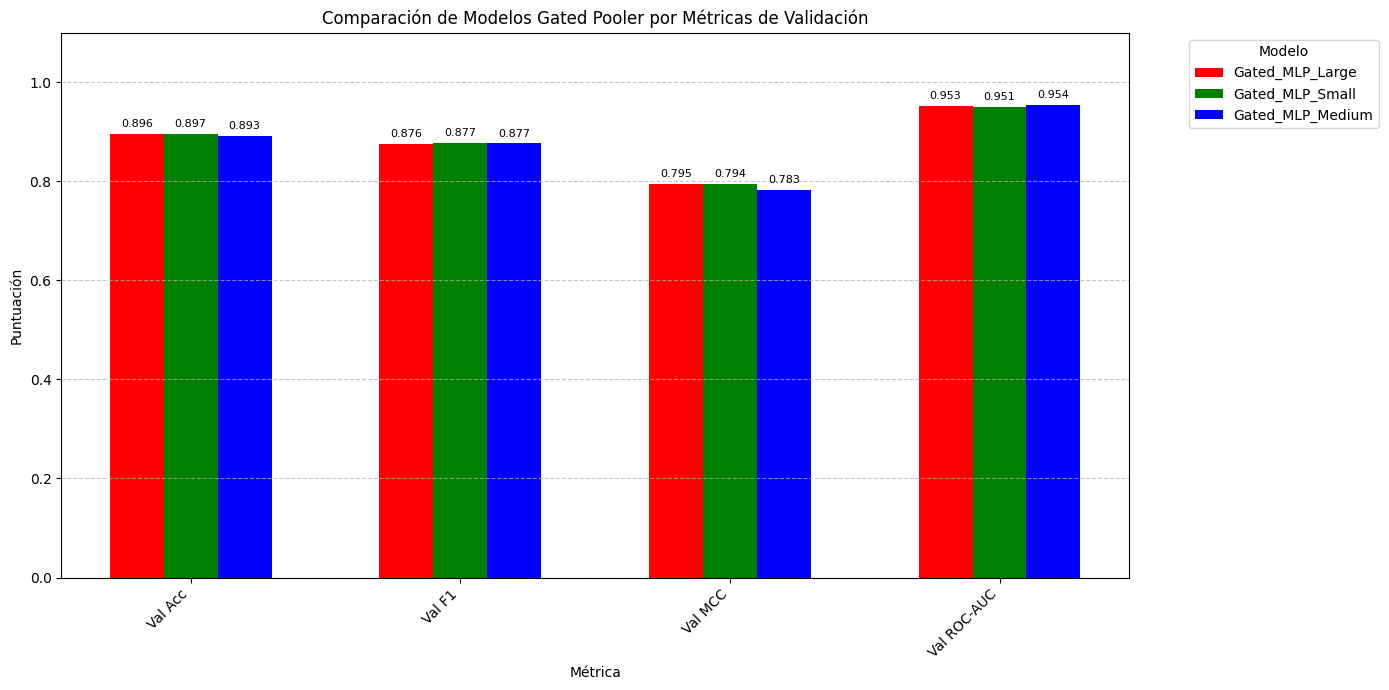

Saved: /kaggle/working/MLP_Results/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: Gated_MLP_Large
   Parameters: 2,956,034
   Best epoch: 7
   Val loss:   0.049746

Saved:
  Checkpoint:    /kaggle/working/MLP_Results/best_model_final.pth
  Training log:  /kaggle/working/MLP_Results/best_model_training_log.csv
  Val metrics:   /kaggle/working/MLP_Results/best_model_val_metrics.json


# 🏆 Conclusión: Mejor Arquitectura Seleccionada

Tras completar el proceso de experimentación y comparación de arquitecturas, se concluye que la configuración **Gated_MLP_Large** ofrece el mejor rendimiento.

### 📊 Resultados Destacados
* **Máxima Discriminación:** Logró el mayor **MCC de validación (0.7946)**, la menor **Val Loss (0.0497)** y el mejor **PR-AUC (0.9575)**, demostrando la mejor capacidad para equilibrar sensibilidad y especificidad en la clasificación de péptidos.
* **Convergencia Rápida y Estable:** Gracias al *Gated Pooling*, las capas *BatchNorm* y un *Dropout* del 0.4, el modelo convergió de forma robusta en solo la **época 7**, manteniendo una brecha mínima entre entrenamiento y validación y evitando sobreajuste.
* **Rendimiento Balanceado:** Con un **Accuracy de 0.8962**, **F1 de 0.8760** y **ROC-AUC de 0.9532**, se posiciona como la arquitectura más precisa y mejor calibrada del conjunto evaluado.

### 📈 Comparativa Rápida

| Modelo | Parámetros | Best Epoch | Val MCC | Val Acc | Val ROC-AUC |
|---|---|---|---|---|---|
| **Gated_MLP_Large** 🏆 | 2,956,034 | 7 | **0.7946** | 0.8962 | 0.9532 |
| Gated_MLP_Small | 1,116,418 | 8 | 0.7940 | **0.8965** | 0.9509 |
| Gated_MLP_Medium | 1,642,242 | 7 | 0.7834 | 0.8926 | **0.9538** |

### 📦 Estado Final & Despliegue
El modelo ganador ha sido exportado y serializado junto con sus metadatos de trazabilidad:
* `best_model_final.pth` → Checkpoint completo (state_dict, config, métricas, historia)
* `best_model_training_log.csv` → Evolución por época (loss, acc, LR, ROC-AUC)
* `best_model_val_metrics.json` → Métricas de validación finales en formato estructurado